Loaded cleaned dataset: (303, 21)
        age       sex  trestbps      chol       fbs   thalach     exang  \
0  0.948726  0.686202  0.757525 -0.264900  2.394438  0.017197 -0.696631   
1  1.392002  0.686202  1.611220  0.760415 -0.417635 -1.821905  1.435481   
2  1.392002  0.686202 -0.665300 -0.342283 -0.417635 -0.902354  1.435481   
3 -1.932564  0.686202 -0.096170  0.063974 -0.417635  1.637359 -0.696631   
4 -1.489288 -1.457296 -0.096170 -0.825922 -0.417635  0.980537 -0.696631   

    oldpeak  target    cp_2.0  ...    cp_4.0  restecg_1.0  restecg_2.0  \
0  1.087338       0 -0.444554  ... -0.951662    -0.115663     1.023375   
1  0.397182       2 -0.444554  ...  1.050793    -0.115663     1.023375   
2  1.346147       1 -0.444554  ...  1.050793    -0.115663     1.023375   
3  2.122573       0 -0.444554  ... -0.951662    -0.115663    -0.977158   
4  0.310912       0  2.249444  ... -0.951662    -0.115663     1.023375   

   slope_2.0  slope_3.0  thal_6.0  thal_7.0    ca_1.0    ca_2.0    ca_

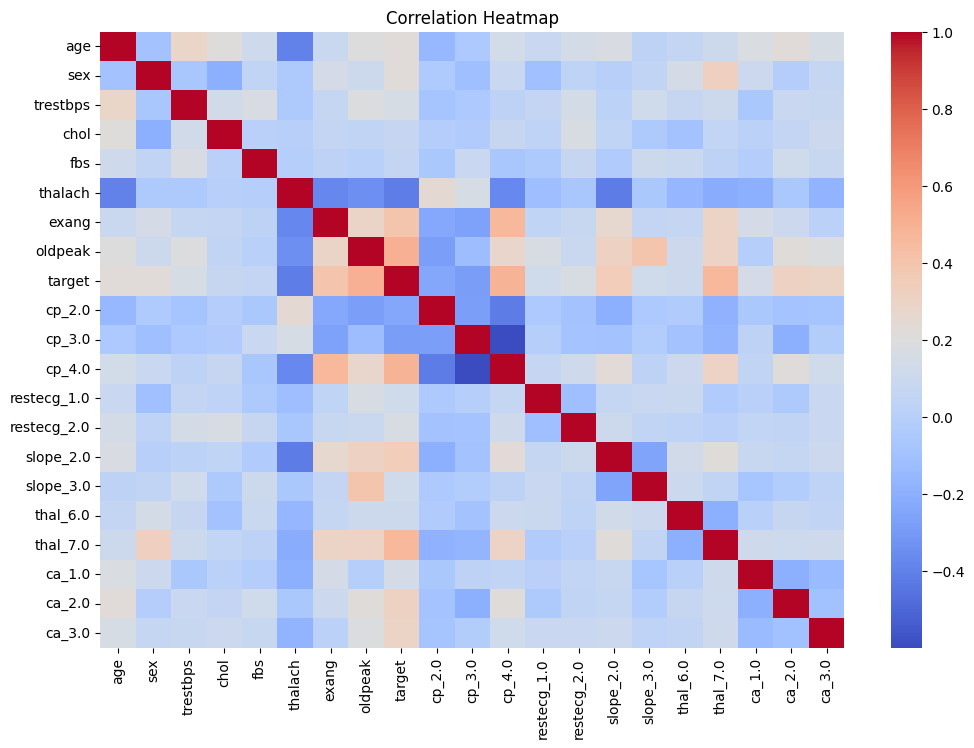

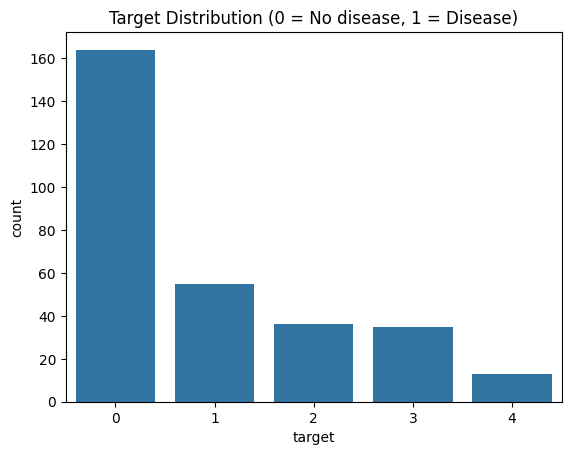

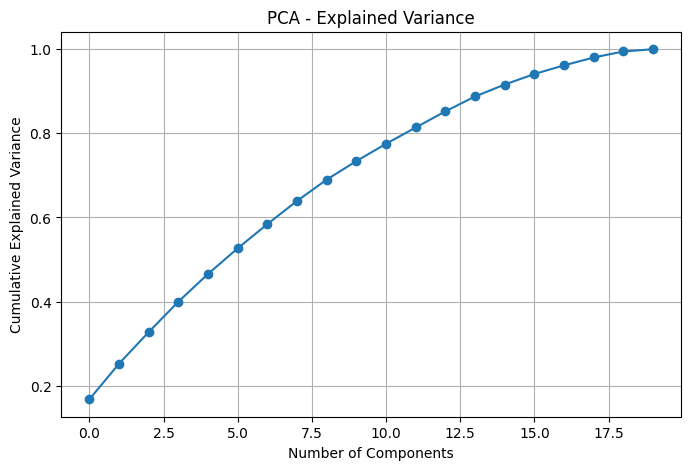

Variance explained by first 5 components: [0.16780623 0.08476876 0.07514196 0.07224269 0.06593154]


In [1]:
# 02 - PCA Analysis

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# 1) Load cleaned dataset
clean_path = "../data/heart_disease_cleaned.csv"
assert os.path.exists(clean_path), (
    f"Cleaned dataset not found at {clean_path}. Please run 01_data_preprocessing first."
)
df = pd.read_csv(clean_path)
print("Loaded cleaned dataset:", df.shape)
print(df.head())

# 2) EDA: Correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap")
plt.show()

# 3) EDA: Target distribution
sns.countplot(x="target", data=df)
plt.title("Target Distribution (0 = No disease, 1 = Disease)")
plt.show()

# 4) PCA
X = df.drop("target", axis=1)
y = df["target"]

pca = PCA()
X_pca = pca.fit_transform(X)

# Explained variance plot
plt.figure(figsize=(8, 5))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA - Explained Variance")
plt.grid()
plt.show()

print("Variance explained by first 5 components:", pca.explained_variance_ratio_[:5])